# 06. EQTransformer Augmentation 실험

**목적**: 합성 M≥4 파형으로 EQTransformer 학습 → r배율 증강에 따른 탐지 성능 비교

**실험 설계** (PDF 10페이지 기준)
- **1단계 (TSTR)**: 합성 데이터만으로 학습 → 실제 M≥4 데이터로 테스트
- **2단계 (Augmentation)**: 실제 데이터 + r배 합성 데이터로 학습
  - r = 0 (실제만), r = 1, r = 10, r = 50

**평가 지표**: Accuracy, Precision, Recall (지진 탐지 이진 분류)

**실행 순서**
1. 셀 1~5: 환경 설정
2. 셀 6: 데이터셋 구성 (실제 + 합성)
3. 셀 7: EQTransformer 경량 구현
4. 셀 8: r별 학습 루프
5. 셀 9: 결과 비교 테이블 출력

In [1]:
# 셀 1. Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 셀 2. 라이브러리 설치
!pip install torch torchaudio numpy pandas h5py scikit-learn matplotlib tqdm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import h5py, os, json, glob, time
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [3]:
# 셀 3. 경로 및 하이퍼파라미터 설정
import os

STEAD_HDF5   = '/content/drive/MyDrive/ML_Project/chunk3.hdf5'
STEAD_CSV    = '/content/drive/MyDrive/ML_Project/chunk3.csv'
STEAD_HDF5_4 = '/content/drive/MyDrive/ML_Project/chunk4.hdf5'
STEAD_CSV4   = '/content/drive/MyDrive/ML_Project/chunk4.csv'
STEAD_HDF5_1 = '/content/drive/MyDrive/ML_Project/chunk1.hdf5'
STEAD_CSV1   = '/content/drive/MyDrive/ML_Project/chunk1.csv'
SYNTHETIC_DIR = '/content/drive/MyDrive/ML_Project/outputs/synthetic_waveforms'
RESULT_DIR    = '/content/drive/MyDrive/ML_Project/outputs/eqtransformer_results'
os.makedirs(RESULT_DIR, exist_ok=True)

N_SAMPLES    = 6000
SR           = 100
N_TEST       = 200
N_REAL_TRAIN = 300
R_LIST = [0, 1, 10, 50, 100]

BATCH_SIZE   = 32
N_EPOCHS     = 50
LR           = 1e-3
PATIENCE     = 15

print('✅ 설정 완료')

✅ 설정 완료


In [4]:
# 셀 4. 실제 데이터 로드 및 분할
# ─────────────────────────────────────────────────────────────────────
# EQTransformer 이진 분류:
#   Label 1 = M≥4 지진 (우리가 관심있는 클래스)
#   Label 0 = 노이즈 / M<2 소형 지진 (negative class)
# ─────────────────────────────────────────────────────────────────────

def load_real_data(hdf5_path, csv_path, chunk_id, mag_min=None, mag_max=None,
                   n_samples_limit=None, random_state=42):
    """STEAD HDF5에서 실제 파형 로드"""
    df = pd.read_csv(csv_path, low_memory=False)

    # 지진 이벤트만 (noise 제외)
    df = df[df['trace_category'] == 'earthquake_local'].copy()
    if mag_min is not None:
        df = df[df['source_magnitude'] >= mag_min]
    if mag_max is not None:
        df = df[df['source_magnitude'] < mag_max]
    if n_samples_limit:
        df = df.sample(n=min(n_samples_limit, len(df)), random_state=random_state)

    waveforms, labels = [], []
    with h5py.File(hdf5_path, 'r') as f:
        for _, row in df.iterrows():
            try:
                wf = f['data'][row['trace_name']][:N_SAMPLES, :].astype(np.float32).mean(axis=1)
                peak = np.abs(wf).max()
                if peak > 1e-10:
                    wf = wf / peak
                waveforms.append(wf)
                labels.append(1 if row['source_magnitude'] >= 4.0 else 0)
            except KeyError:
                continue

    return np.array(waveforms, dtype=np.float32), np.array(labels, dtype=np.int64)


print('실제 M≥4 데이터 로드 중...')

# M≥4 실제 데이터 (train + test 분리)
wf_real_m4_3, _ = load_real_data(STEAD_HDF5, STEAD_CSV, 3, mag_min=4.0)
wf_real_m4_4, _ = load_real_data(STEAD_HDF5_4, STEAD_CSV4, 4, mag_min=4.0)
wf_real_m4 = np.concatenate([wf_real_m4_3, wf_real_m4_4], axis=0)
np.random.seed(42)
np.random.shuffle(wf_real_m4)

wf_test  = wf_real_m4[:N_TEST]             # 테스트 고정 (절대 학습 사용 금지)
wf_train_real = wf_real_m4[N_TEST:N_TEST+N_REAL_TRAIN]  # 학습용 실제 데이터
label_test    = np.ones(N_TEST, dtype=np.int64)
label_train_real = np.ones(N_REAL_TRAIN, dtype=np.int64)

# Negative class (chunk1 noise)
STEAD_HDF5_1 = '/content/drive/MyDrive/ML_Project/chunk1.hdf5'
STEAD_CSV1   = '/content/drive/MyDrive/ML_Project/chunk1.csv'

def load_noise_data(hdf5_path, csv_path, n_limit):
    df = pd.read_csv(csv_path, low_memory=False)
    df = df[df['trace_category'] == 'noise'].sample(
        n=min(n_limit, len(df)), random_state=42
    )
    waveforms = []
    with h5py.File(hdf5_path, 'r') as f:
        for _, row in df.iterrows():
            try:
                wf = f['data'][row['trace_name']][:N_SAMPLES, :].astype(np.float32).mean(axis=1)
                peak = np.abs(wf).max()
                if peak > 1e-10:
                    wf = wf / peak
                waveforms.append(wf)
            except KeyError:
                continue
    return np.array(waveforms, dtype=np.float32)

wf_neg_all   = load_noise_data(STEAD_HDF5_1, STEAD_CSV1, N_TEST + N_REAL_TRAIN)
wf_neg_test  = wf_neg_all[:N_TEST]
wf_neg_train = wf_neg_all[N_TEST:N_TEST+N_REAL_TRAIN]
label_neg_test  = np.zeros(N_TEST, dtype=np.int64)
label_neg_train = np.zeros(N_REAL_TRAIN, dtype=np.int64)
print(f'실제 M≥4 전체: {len(wf_real_m4):,}개')
print(f'  test:       {len(wf_test):,}개 (고정)')
print(f'  train(real): {len(wf_train_real):,}개')
print(f'Negative:     {len(wf_neg_all):,}개')

실제 M≥4 데이터 로드 중...
실제 M≥4 전체: 7,640개
  test:       200개 (고정)
  train(real): 300개
Negative:     500개


In [5]:
# 셀 5. Dataset 클래스

class SeismicClassifyDataset(Dataset):
    def __init__(self, waveforms, labels, augment=False):
        self.X = torch.tensor(waveforms, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x, y = self.X[idx], self.y[idx]
        if self.augment and torch.rand(1).item() < 0.5:
            shift = int(torch.randint(-600, 600, (1,)).item())
            x = torch.roll(x, shift, dims=-1)
        return x, y


def load_synthetic(M, n, synthetic_dir):
    """M별 all.npy에서 n개 로드 + peak 정규화"""
    all_wf = np.load(os.path.join(synthetic_dir, f'M{M:.1f}_all.npy'))
    wfs = all_wf[:n].astype(np.float32)
    for i in range(len(wfs)):
        peak = np.abs(wfs[i]).max()
        if peak > 1e-10:
            wfs[i] = wfs[i] / peak
    return wfs


def build_dataset(r, wf_train_real, label_train_real,
                  wf_neg_train, label_neg_train,
                  synthetic_dir, n_real):
    pos_wf = [wf_train_real]
    pos_lb = [label_train_real]

    if r > 0:
        n_syn_per_M = (n_real * r) // 4
        for M in [4.0, 5.0, 6.0, 7.0]:
            try:
                syn_wfs = load_synthetic(M, n_syn_per_M, synthetic_dir)
                pos_wf.append(syn_wfs)
                pos_lb.append(np.ones(len(syn_wfs), dtype=np.int64))
            except Exception as e:
                print(f'⚠️  M={M} 로드 실패: {e}')
                continue

    pos_wf = np.concatenate(pos_wf, axis=0)
    pos_lb = np.concatenate(pos_lb, axis=0)

    n_pos = len(pos_wf)
    neg_wf = np.tile(wf_neg_train,
                     (n_pos // len(wf_neg_train) + 1, 1))[:n_pos]
    neg_lb = np.zeros(n_pos, dtype=np.int64)

    all_wf = np.concatenate([pos_wf, neg_wf], axis=0)
    all_lb = np.concatenate([pos_lb, neg_lb], axis=0)
    idx = np.random.permutation(len(all_wf))
    return all_wf[idx], all_lb[idx]


print('✅ Dataset 클래스 정의 완료')

✅ Dataset 클래스 정의 완료


In [6]:
# 셀 6. EQTransformer 경량 구현
# ─────────────────────────────────────────────────────────────────────
# 원본 EQTransformer는 P/S파 picking까지 수행하지만,
# 여기서는 지진 탐지 (이진 분류)에 집중한 경량 버전 구현
# 핵심 구조: Conv1D Encoder → LSTM → Self-Attention → Binary Classifier
# ─────────────────────────────────────────────────────────────────────

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=11, dropout=0.1):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              padding=kernel_size//2, bias=False)
        self.bn   = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(F.relu(self.bn(self.conv(x))))


class SelfAttention1D(nn.Module):
    def __init__(self, d_model, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, C, T) → (B, T, C)
        x = x.permute(0, 2, 1)
        attn_out, _ = self.attn(x, x, x)
        x = self.norm(x + attn_out)
        return x.permute(0, 2, 1)  # (B, C, T)


class EQTransformerDetector(nn.Module):
    """
    EQTransformer 경량 지진 탐지기
    Input:  (B, 1, 6000) — 단성분 파형
    Output: (B, 2)       — [noise, earthquake] logits
    """
    def __init__(self, dropout=0.1):
        super().__init__()

        # ── Encoder (Conv 블록 ×4, 점진적 채널 증가 + 다운샘플) ──────
        self.encoder = nn.Sequential(
            ConvBlock(1,   32,  11, dropout),
            nn.MaxPool1d(2),         # 6000 → 3000
            ConvBlock(32,  64,  9,  dropout),
            nn.MaxPool1d(2),         # 3000 → 1500
            ConvBlock(64, 128,  7,  dropout),
            nn.MaxPool1d(2),         # 1500 → 750
            ConvBlock(128, 256, 5,  dropout),
            nn.MaxPool1d(2),         # 750  → 375
        )

        # ── Self-Attention ──────────────────────────────────────────
        self.attn = SelfAttention1D(256, n_heads=4)

        # ── Bi-LSTM ─────────────────────────────────────────────────
        self.lstm = nn.LSTM(256, 128, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=dropout)

        # ── Classifier ──────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # Encoding
        h = self.encoder(x)           # (B, 256, 375)

        # Self-Attention
        h = self.attn(h)              # (B, 256, 375)

        # Bi-LSTM
        h = h.permute(0, 2, 1)       # (B, 375, 256)
        h, _ = self.lstm(h)          # (B, 375, 256)

        # Global Average Pooling
        h = h.mean(dim=1)            # (B, 256)

        return self.classifier(h)    # (B, 2)


# 모델 크기 확인
test_model = EQTransformerDetector()
n_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f'EQTransformer 파라미터 수: {n_params:,}')
test_in = torch.randn(4, 1, 6000)
test_out = test_model(test_in)
print(f'입력: {test_in.shape} → 출력: {test_out.shape}')
print('✅ 모델 정의 완료')

EQTransformer 파라미터 수: 1,311,714
입력: torch.Size([4, 1, 6000]) → 출력: torch.Size([4, 2])
✅ 모델 정의 완료


In [7]:
# 셀 7. 학습 / 평가 함수

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total   += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for X, y in loader:
        X = X.to(device)
        preds = model(X).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'confusion': cm}


def run_experiment(r, save_prefix):
    """
    r배율 실험 1회 실행
    Returns: dict with accuracy, precision, recall
    """
    print(f'\n{'='*50}')
    print(f'  실험: r={r} 배율 증강')
    print(f'{'='*50}')

    # 데이터셋 구성
    train_wf, train_lb = build_dataset(
        r, wf_train_real, label_train_real,
        wf_neg_train, label_neg_train,
        SYNTHETIC_DIR, N_REAL_TRAIN
    )
    print(f'  학습 데이터: {len(train_wf):,}개 (pos={train_lb.sum():,}, neg={(train_lb==0).sum():,})')

    # 테스트 데이터 (고정)
    test_wf = np.concatenate([wf_test, wf_neg_test], axis=0)
    test_lb = np.concatenate([label_test, label_neg_test], axis=0)

    train_ds = SeismicClassifyDataset(train_wf, train_lb, augment=True)
    test_ds  = SeismicClassifyDataset(test_wf,  test_lb,  augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # 모델 초기화 (매 실험마다 새로 시작)
    model = EQTransformerDetector(dropout=0.15).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    # 학습
    best_acc = 0
    patience_cnt = 0
    best_ckpt = os.path.join(RESULT_DIR, f'{save_prefix}_r{r}_best.pth')

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        metrics = evaluate(model, test_loader)
        scheduler.step()

        if metrics['accuracy'] > best_acc:
            best_acc = metrics['accuracy']
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'metrics': metrics}, best_ckpt)
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep{epoch:3d}: loss={tr_loss:.4f} | '
                  f'Acc={metrics["accuracy"]:.4f} '
                  f'Prec={metrics["precision"]:.4f} '
                  f'Rec={metrics["recall"]:.4f}')

        if patience_cnt >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break

    # 최고 체크포인트 로드 후 최종 평가
    best_state = torch.load(best_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(best_state['model'])
    final_metrics = evaluate(model, test_loader)

    print(f'\n  ── 최종 결과 (r={r}) ──')
    print(f'  Accuracy : {final_metrics["accuracy"]:.4f}')
    print(f'  Precision: {final_metrics["precision"]:.4f}')
    print(f'  Recall   : {final_metrics["recall"]:.4f}')
    print(f'  Confusion:\n{final_metrics["confusion"]}')

    return {
        'r': r,
        'n_train_pos': int(train_lb.sum()),
        'n_train_total': len(train_lb),
        'accuracy':  final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall':    final_metrics['recall'],
    }


print('✅ 학습/평가 함수 정의 완료')

✅ 학습/평가 함수 정의 완료


In [10]:
# 셀 8-0. 품질 검증: Train on Real, Test on Synthetic

def run_real_to_synthetic():
    print('\n' + '='*50)
    print('  품질 검증: Train on Real, Test on Synthetic')
    print('='*50)

    # 학습: 실제 M≥4 + 실제 noise
    train_wf = np.concatenate([wf_train_real, wf_neg_train], axis=0)
    train_lb = np.concatenate([label_train_real, label_neg_train], axis=0)
    idx = np.random.permutation(len(train_wf))
    train_wf, train_lb = train_wf[idx], train_lb[idx]

    # 테스트: 합성 M≥4 + 실제 noise
    n_syn_per_M = N_TEST // 4
    syn_wfs = []
    for M in [4.0, 5.0, 6.0, 7.0]:
        wfs = load_synthetic(M, n_syn_per_M, SYNTHETIC_DIR)
        syn_wfs.append(wfs)

    syn_wf = np.concatenate(syn_wfs, axis=0)
    syn_lb = np.ones(len(syn_wf), dtype=np.int64)

    test_wf = np.concatenate([syn_wf, wf_neg_test], axis=0)
    test_lb = np.concatenate([syn_lb, label_neg_test], axis=0)

    print(f'  학습 데이터: {len(train_wf):,}개 (실제만)')
    print(f'  테스트 데이터: {len(test_wf):,}개 (합성 {len(syn_wf)}개 + noise {len(wf_neg_test)}개)')

    train_ds = SeismicClassifyDataset(train_wf, train_lb, augment=True)
    test_ds  = SeismicClassifyDataset(test_wf,  test_lb,  augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = EQTransformerDetector(dropout=0.15).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    patience_cnt = 0
    best_ckpt = os.path.join(RESULT_DIR, 'eqt_trts_best.pth')

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        metrics = evaluate(model, test_loader)
        scheduler.step()

        if metrics['accuracy'] > best_acc:
            best_acc = metrics['accuracy']
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'metrics': metrics}, best_ckpt)
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep{epoch:3d}: loss={tr_loss:.4f} | '
                  f'Acc={metrics["accuracy"]:.4f} '
                  f'Prec={metrics["precision"]:.4f} '
                  f'Rec={metrics["recall"]:.4f}')

        if patience_cnt >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break

    best_state = torch.load(best_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(best_state['model'])
    final_metrics = evaluate(model, test_loader)

    print(f'\n  ── 최종 결과 (TRTS) ──')
    print(f'  Accuracy : {final_metrics["accuracy"]:.4f}')
    print(f'  Precision: {final_metrics["precision"]:.4f}')
    print(f'  Recall   : {final_metrics["recall"]:.4f}')
    print(f'  Confusion:\n{final_metrics["confusion"]}')
    print(f'\n  해석: Recall이 높으면 합성 파형이 실제처럼 생긴 것')

    return {
        'experiment': 'TRTS',
        'accuracy':  final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall':    final_metrics['recall'],
    }

real_to_syn_result = run_real_to_synthetic()
print('✅ TRTS 완료')


  품질 검증: Train on Real, Test on Synthetic
  학습 데이터: 600개 (실제만)
  테스트 데이터: 400개 (합성 200개 + noise 200개)
  Ep  1: loss=0.3690 | Acc=0.0100 Prec=0.0000 Rec=0.0000
  Ep  5: loss=0.1522 | Acc=0.4900 Prec=0.0000 Rec=0.0000
  Ep 10: loss=0.1221 | Acc=0.4950 Prec=0.0000 Rec=0.0000
  Ep 15: loss=0.0719 | Acc=0.4950 Prec=0.0000 Rec=0.0000
  Ep 20: loss=0.0512 | Acc=0.4950 Prec=0.0000 Rec=0.0000
  Ep 25: loss=0.0606 | Acc=0.4925 Prec=0.0000 Rec=0.0000
  Ep 30: loss=0.0315 | Acc=0.5000 Prec=0.0000 Rec=0.0000
  Ep 35: loss=0.0244 | Acc=0.4975 Prec=0.0000 Rec=0.0000
  Early stop at epoch 36

  ── 최종 결과 (TRTS) ──
  Accuracy : 0.5000
  Precision: 0.0000
  Recall   : 0.0000
  Confusion:
[[200   0]
 [200   0]]

  해석: Recall이 높으면 합성 파형이 실제처럼 생긴 것
✅ TRTS 완료


In [14]:
# 셀 8-1. TSTR: Train on Synthetic, Test on Real

def run_tstr():
    print('\n' + '='*50)
    print('  TSTR: Train on Synthetic, Test on Real')
    print('='*50)

    n_syn_per_M = N_REAL_TRAIN
    syn_wfs, syn_lbs = [], []
    for M in [4.0, 5.0, 6.0, 7.0]:
        wfs = load_synthetic(M, n_syn_per_M, SYNTHETIC_DIR)
        syn_wfs.append(wfs)
        syn_lbs.append(np.ones(len(wfs), dtype=np.int64))

    syn_wf = np.concatenate(syn_wfs, axis=0)
    syn_lb = np.concatenate(syn_lbs, axis=0)

    n_pos = len(syn_wf)
    neg_wf = np.tile(wf_neg_train,
                     (n_pos // len(wf_neg_train) + 1, 1))[:n_pos]
    neg_lb = np.zeros(n_pos, dtype=np.int64)

    train_wf = np.concatenate([syn_wf, neg_wf], axis=0)
    train_lb = np.concatenate([syn_lb, neg_lb], axis=0)
    idx = np.random.permutation(len(train_wf))
    train_wf, train_lb = train_wf[idx], train_lb[idx]

    print(f'  학습 데이터: {len(train_wf):,}개 (합성만)')

    test_wf = np.concatenate([wf_test, wf_neg_test], axis=0)
    test_lb = np.concatenate([label_test, label_neg_test], axis=0)

    train_ds = SeismicClassifyDataset(train_wf, train_lb, augment=False)
    test_ds  = SeismicClassifyDataset(test_wf,  test_lb,  augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = EQTransformerDetector(dropout=0.15).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    patience_cnt = 0
    best_ckpt = os.path.join(RESULT_DIR, 'eqt_tstr_best.pth')

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        metrics = evaluate(model, test_loader)
        scheduler.step()

        if metrics['accuracy'] > best_acc:
            best_acc = metrics['accuracy']
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'metrics': metrics}, best_ckpt)
            patience_cnt = 0
        else:
            patience_cnt += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep{epoch:3d}: loss={tr_loss:.4f} | '
                  f'Acc={metrics["accuracy"]:.4f} '
                  f'Prec={metrics["precision"]:.4f} '
                  f'Rec={metrics["recall"]:.4f}')

        if patience_cnt >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break

    best_state = torch.load(best_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(best_state['model'])
    final_metrics = evaluate(model, test_loader)

    print(f'\n  ── TSTR 최종 결과 ──')
    print(f'  Accuracy : {final_metrics["accuracy"]:.4f}')
    print(f'  Precision: {final_metrics["precision"]:.4f}')
    print(f'  Recall   : {final_metrics["recall"]:.4f}')
    print(f'  Confusion:\n{final_metrics["confusion"]}')

    return {
        'experiment': 'TSTR',
        'accuracy':  final_metrics['accuracy'],
        'precision': final_metrics['precision'],
        'recall':    final_metrics['recall'],
    }

tstr_result = run_tstr()
print('✅ TSTR 완료')


  TSTR: Train on Synthetic, Test on Real
  학습 데이터: 2,400개 (합성만)
  Ep  1: loss=0.0555 | Acc=0.5000 Prec=0.0000 Rec=0.0000
  Ep  5: loss=0.0000 | Acc=0.5000 Prec=0.0000 Rec=0.0000
  Ep 10: loss=0.0000 | Acc=0.5000 Prec=0.0000 Rec=0.0000
  Ep 15: loss=0.0000 | Acc=0.5000 Prec=0.0000 Rec=0.0000
  Early stop at epoch 16

  ── TSTR 최종 결과 ──
  Accuracy : 0.5000
  Precision: 0.0000
  Recall   : 0.0000
  Confusion:
[[200   0]
 [200   0]]
✅ TSTR 완료


In [15]:
# 셀 8-2. r별 Augmentation 실험

results = []

for r in R_LIST:
    result = run_experiment(r, save_prefix='eqt')
    results.append(result)
    pd.DataFrame(results).to_csv(
        os.path.join(RESULT_DIR, 'augmentation_results.csv'), index=False
    )

print('\n✅ 전체 실험 완료!')


  실험: r=0 배율 증강
  학습 데이터: 600개 (pos=300, neg=300)
  Ep  1: loss=0.3457 | Acc=0.5200 Prec=0.5102 Rec=1.0000
  Ep  5: loss=0.1745 | Acc=0.9425 Prec=0.9784 Rec=0.9050
  Ep 10: loss=0.1330 | Acc=0.9475 Prec=0.9735 Rec=0.9200
  Ep 15: loss=0.1054 | Acc=0.8675 Prec=0.9804 Rec=0.7500
  Early stop at epoch 19

  ── 최종 결과 (r=0) ──
  Accuracy : 0.9725
  Precision: 0.9610
  Recall   : 0.9850
  Confusion:
[[192   8]
 [  3 197]]

  실험: r=1 배율 증강
  학습 데이터: 1,200개 (pos=600, neg=600)
  Ep  1: loss=0.3069 | Acc=0.8875 Prec=0.8189 Rec=0.9950
  Ep  5: loss=0.2158 | Acc=0.9400 Prec=0.9231 Rec=0.9600
  Ep 10: loss=0.1623 | Acc=0.5125 Prec=0.7273 Rec=0.0400
  Ep 15: loss=0.1450 | Acc=0.6400 Prec=0.9516 Rec=0.2950
  Ep 20: loss=0.0888 | Acc=0.6425 Prec=0.9524 Rec=0.3000
  Ep 25: loss=0.0844 | Acc=0.5575 Prec=0.8966 Rec=0.1300
  Early stop at epoch 27

  ── 최종 결과 (r=1) ──
  Accuracy : 0.9575
  Precision: 0.9463
  Recall   : 0.9700
  Confusion:
[[189  11]
 [  6 194]]

  실험: r=10 배율 증강
  학습 데이터: 6,600개 (pos=3,

In [16]:
# 현재까지 결과 확인
import pandas as pd
res_df = pd.read_csv('/content/drive/MyDrive/ML_Project/outputs/eqtransformer_results/augmentation_results.csv')
print(res_df)

     r  n_train_pos  n_train_total  accuracy  precision  recall
0    0          300            600    0.9725   0.960976   0.985
1    1          600           1200    0.9575   0.946341   0.970
2   10         3300           6600    0.9675   0.989529   0.945
3   50        15300          30600    0.5000   0.000000   0.000
4  100        30300          60600    0.5000   0.000000   0.000



── TSTR 결과 ──
  Accuracy : 0.5000
  Precision: 0.0000
  Recall   : 0.0000

          EQTransformer Augmentation 실험 결과

── Accuracy ──
       r배율 |          값 |    r=0 대비 변화
--------------------------------------
   r0(실제만) |     0.9725 |            —
        r1 |     0.9575 |      -0.0150
       r10 |     0.9675 |      -0.0050
       r50 |     0.5000 |      -0.4725
      r100 |     0.5000 |      -0.4725

── Precision ──
       r배율 |          값 |    r=0 대비 변화
--------------------------------------
   r0(실제만) |     0.9610 |            —
        r1 |     0.9463 |      -0.0146
       r10 |     0.9895 |      +0.0286
       r50 |     0.0000 |      -0.9610
      r100 |     0.0000 |      -0.9610

── Recall ──
       r배율 |          값 |    r=0 대비 변화
--------------------------------------
   r0(실제만) |     0.9850 |            —
        r1 |     0.9700 |      -0.0150
       r10 |     0.9450 |      -0.0400
       r50 |     0.0000 |      -0.9850
      r100 |     0.0000 |      -0.9850


/tmp/ipykernel_1751/2167153785.py:51: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1751/2167153785.py:51: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1751/2167153785.py:52: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(RESULT_DIR, 'augmentation_results.png'), dpi=150, bbox_inches='tight')
/tmp/ipykernel_1751/2167153785.py:52: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(RESULT_DIR, 'augmentation_results.png'), dpi=150, bbox_inches='tight')


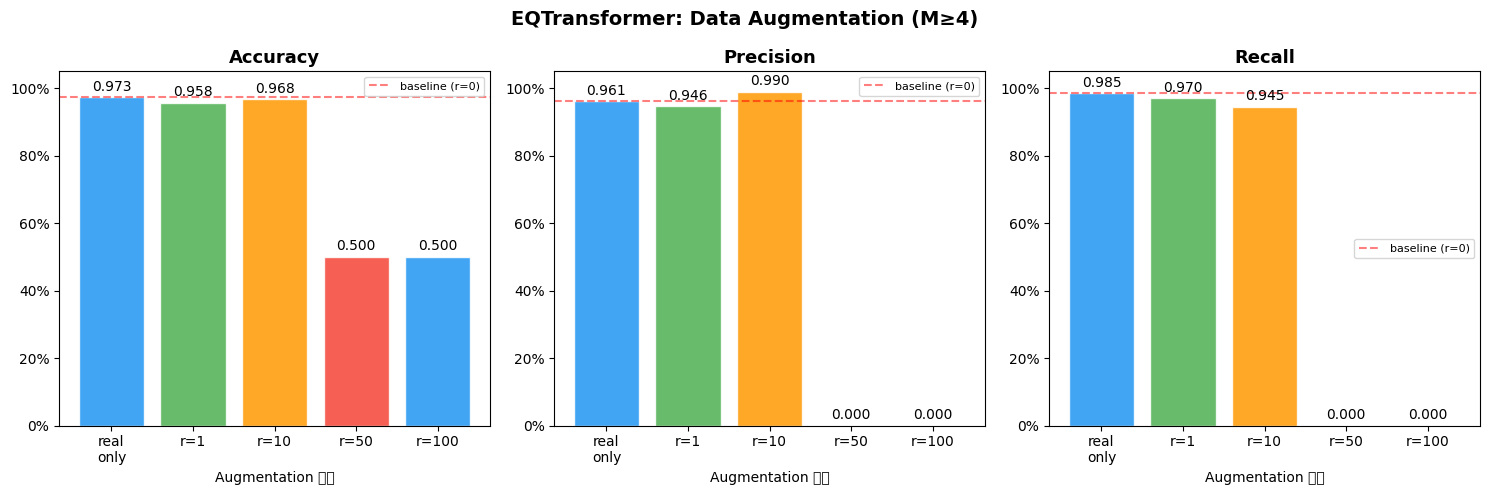


── Recall 개선률 (r=0 대비) ──
  r=  1: -1.5%
  r= 10: -4.1%
  r= 50: -100.0%
  r=100: -100.0%

✅ 결과 저장 완료: /content/drive/MyDrive/ML_Project/outputs/eqtransformer_results


In [18]:
# 셀 9. 결과 시각화 및 보고서용 테이블
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# TSTR 결과 먼저 출력
print('\n── TSTR 결과 ──')
print(f'  Accuracy : {tstr_result["accuracy"]:.4f}')
print(f'  Precision: {tstr_result["precision"]:.4f}')
print(f'  Recall   : {tstr_result["recall"]:.4f}')

res_df = pd.DataFrame(results)

print('\n' + '='*60)
print('          EQTransformer Augmentation 실험 결과')
print('='*60)

metrics = ['accuracy', 'precision', 'recall']
titles  = ['Accuracy', 'Precision', 'Recall']

for metric, title in zip(metrics, titles):
    print(f'\n── {title} ──')
    print(f'{"r배율":>10} | {"값":>10} | {"r=0 대비 변화":>12}')
    print('-'*38)
    baseline = res_df[res_df['r'] == 0][metric].values[0]
    for _, row in res_df.iterrows():
        label = 'r0(실제만)' if row['r'] == 0 else f'r{int(row["r"])}'
        delta = row[metric] - baseline
        delta_str = f'{delta:+.4f}' if row['r'] != 0 else '—'
        print(f'{label:>10} | {row[metric]:>10.4f} | {delta_str:>12}')

# ── 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x_labels = [f'r={int(r)}' if r > 0 else 'real\nonly' for r in res_df['r']]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for ax, metric, title in zip(axes,
    ['accuracy', 'precision', 'recall'],
    ['Accuracy', 'Precision', 'Recall']):
    bars = ax.bar(x_labels, res_df[metric], color=colors[:len(res_df)], alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel('Augmentation 배율')
    ax.axhline(res_df.iloc[0][metric], color='red', linestyle='--', alpha=0.5, label='baseline (r=0)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('EQTransformer: Data Augmentation (M≥4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'augmentation_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Recall 개선률 계산 (핵심 지표) ──────────────────────
baseline_recall = res_df[res_df['r'] == 0]['recall'].values[0]
print('\n── Recall 개선률 (r=0 대비) ──')
for _, row in res_df.iterrows():
    if row['r'] == 0: continue
    improvement = (row['recall'] - baseline_recall) / (baseline_recall + 1e-10) * 100
    print(f'  r={int(row["r"]):>3}: {improvement:+.1f}%')

res_df.to_csv(os.path.join(RESULT_DIR, 'augmentation_results_final.csv'), index=False)
print(f'\n✅ 결과 저장 완료: {RESULT_DIR}')